<a href="https://colab.research.google.com/github/singhprinceraj2210/models/blob/main/lstm_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv("/content/IMDB Dataset.csv")  # columns: text, label

print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Keep important negation words
negation_words = {'not', 'no', 'nor', 'never'}

stop_words = stop_words - negation_words


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):

    text = str(text).lower()

    # remove html tags
    text = re.sub(r'<.*?>', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenization
    words = text.split()

    # remove stopwords
    words = [w for w in words if w not in stop_words]

    return words


# Apply preprocessing
df['tokens'] = df['review'].apply(clean_text)


In [ ]:
from gensim.models import Word2Vec

loaded_model = Word2Vec.load(
    "/content/drive/MyDrive/word2vec_model.model"
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
def vectorize_text(tokens, model):

    vectors = []

    for word in tokens:

        if word in model.wv:
            vectors.append(model.wv[word])

    # Handle empty sentences
    if len(vectors) == 0:
        vectors.append(np.zeros(model.vector_size))

    return vectors


X = []

for tokens in df['tokens']:

    vec = vectorize_text(tokens, loaded_model)

    X.append(vec)

In [ ]:
MAX_LEN = 100

X = pad_sequences(
    X,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='post',
    truncating='post'
)

print("\nX Shape:")
print(X.shape)


X Shape:
(50000, 100, 100)


In [ ]:
y = df['sentiment'].map({
    'positive': 1,
    'negative': 0
}).values

print("\nY Shape:")
print(y.shape)


Y Shape:
(50000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)



Train Shape: (40000, 100, 100)
Test Shape: (10000, 100, 100)


In [ ]:
EMBEDDING_DIM = loaded_model.vector_size
model_lstm = Sequential()

# Input Layer
model_lstm.add(
    Input(shape=(MAX_LEN, EMBEDDING_DIM))
)

# LSTM Layer
model_lstm.add(
    LSTM(
        128,
        return_sequences=False
    )
)

# Batch Normalization
model_lstm.add(BatchNormalization())

# Dropout
model_lstm.add(Dropout(0.5))

# Dense Layer
model_lstm.add(Dense(64, activation='relu'))

# Dropout
model_lstm.add(Dropout(0.5))

# Output Layer
model_lstm.add(Dense(1, activation='sigmoid'))

In [ ]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model_lstm.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,081 (492.50 KB)

 Trainable params: 125,825 (491.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 238ms/step - accuracy: 0.7205 - loss: 0.5707 - val_accuracy: 0.8334 - val_loss: 0.3970
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 218ms/step - accuracy: 0.8430 - loss: 0.3709 - val_accuracy: 0.8268 - val_loss: 0.3760
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.8543 - loss: 0.3432 - val_accuracy: 0.8594 - val_loss: 0.3189
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 141s 226ms/step - accuracy: 0.8661 - loss: 0.3192 - val_accuracy: 0.8413 - val_loss: 0.3584
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 241ms/step - accuracy: 0.8715 - loss: 0.3073 - val_accuracy: 0.8663 - val_loss: 0.3187
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 198s 235ms/step - accuracy: 0.8795 - loss: 0.2928 - val_accuracy: 0.8664 - val_loss: 0.3090
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 224ms/step - accuracy: 0.8845 - loss: 0.2777 - val_accuracy: 0.8664 - val_loss: 0.3201
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.8911 -

In [ ]:

loss, accuracy = model_lstm.evaluate(X_test, y_test)

print("\n================================")
print("TEST ACCURACY")
print("================================")

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8738 - loss: 0.2926

TEST ACCURACY
Accuracy: 0.8737999796867371


In [ ]:
y_pred_prob = model_lstm.predict(X_test)

y_pred = (
    y_pred_prob > 0.5
).astype(int).reshape(-1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step


In [ ]:
print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      5000
           1       0.89      0.86      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
print("\n================================")
print("CONFUSION MATRIX")
print("================================")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)



CONFUSION MATRIX
[[4458  542]
 [ 720 4280]]


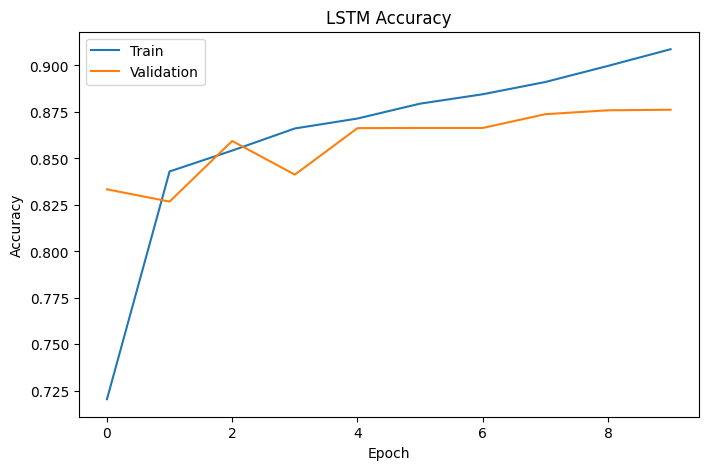

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('LSTM Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

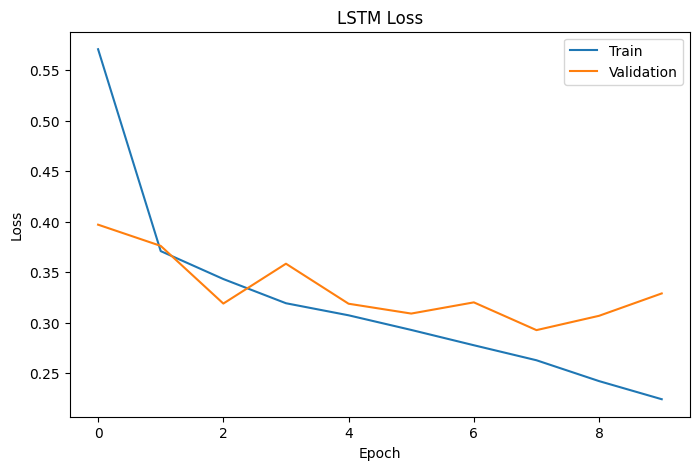

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('LSTM Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model_lstm.save(
    '/content/drive/MyDrive/imdb_lstm_model.keras'
)

In [ ]:
def predict_sentiment(text):

    # clean text
    tokens = clean_text(text)

    # vectorize
    vec = []

    for word in tokens:

        if word in loaded_model.wv:
            vec.append(loaded_model.wv[word])

    # handle empty text
    if len(vec) == 0:
        vec.append(np.zeros(EMBEDDING_DIM))

    # padding
    vec = pad_sequences(
        [vec],
        maxlen=MAX_LEN,
        dtype='float32',
        padding='post',
        truncating='post'
    )
     # prediction
    pred = model_lstm.predict(vec)[0][0]

    if pred > 0.5:
        return f"Positive Sentiment ({pred:.4f})"

    else:
        return f"Negative Sentiment ({pred:.4f})"


In [ ]:
print(
    predict_sentiment(
        "this movie was absolutely amazing but ending is worst"
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Negative Sentiment (0.1623)
